In [54]:
import sys
import os
import pandas as pd
import numpy as np
import csv
import pip
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import statsmodels.api as sm
import linearmodels as lm
from linearmodels import PanelOLS, RandomEffects
from scipy import stats
from linearmodels import RandomEffects
import statsmodels.api as sm
from linearmodels.panel import compare

In [55]:
final_df = pd.read_csv("prepared_data_for_regression.csv")
print(final_df.head(5))

      country  year  incidence  mortality           gdp       bmi    pop_65  \
0        fiji  2000  39.310026  33.722967   9426.113813  0.303726  3.437768   
1    cambodia  2000  11.807551  10.664151   1922.031791  0.100004  2.816518   
2    kiribati  2000  13.866566  12.601468   2481.415243  0.307055  3.413156   
3  kazakhstan  2000  35.284421  18.655098  12935.864368  0.291659  6.693366   
4     jamaica  2000  50.404926  25.599975   9518.231763  0.240683  6.060642   

   urban_pop  fertility  labor_rate  internet  health_exp  smoking  
0     47.908      2.992      37.841  1.496850    3.424412     15.9  
1     18.586      3.794      77.834  0.047023    6.482484     23.5  
2     42.958      4.071         NaN  1.785230    7.773798     53.9  
3     56.098      1.898      65.381  0.668594    4.160324     12.0  
4     51.814      2.345      58.147  3.115780    5.644625      8.8  


In [56]:
initial_countries=final_df['country'].nunique()
print(initial_countries)

171


In [57]:
initial_years=final_df['year'].nunique()
print(initial_years)

24


# OECD  Countries :

In [58]:
oecd_countries = ['austria', 'australia', 'belgium', 'canada', 'chile', 
                  'colombia', 'czechia', 'denmark', 'estonia', 'finland', 
                  'france', 'germany', 'greece', 'hungary', 'iceland', 'ireland', 
                  'israel', 'italy', 'japan', 'korea', 'latvia', 'lithuania', 'luxembourg', 
                  'mexico', 'netherlands', 'new zealand', 'norway', 'poland', 'portugal', 'slovakia', 
                  'slovenia', 'spain', 'sweden', 'switzerland', 'turkiye', 'united kingdom', 'united states', 'costa rica']
print(len(oecd_countries))

38


# Creat Dummy Variables:

In [59]:
final_df['is_oecd'] = final_df['country'].isin(oecd_countries).astype(int)

# creat interaction :

is_oecd
0    3250
1     816
Name: count, dtype: int64


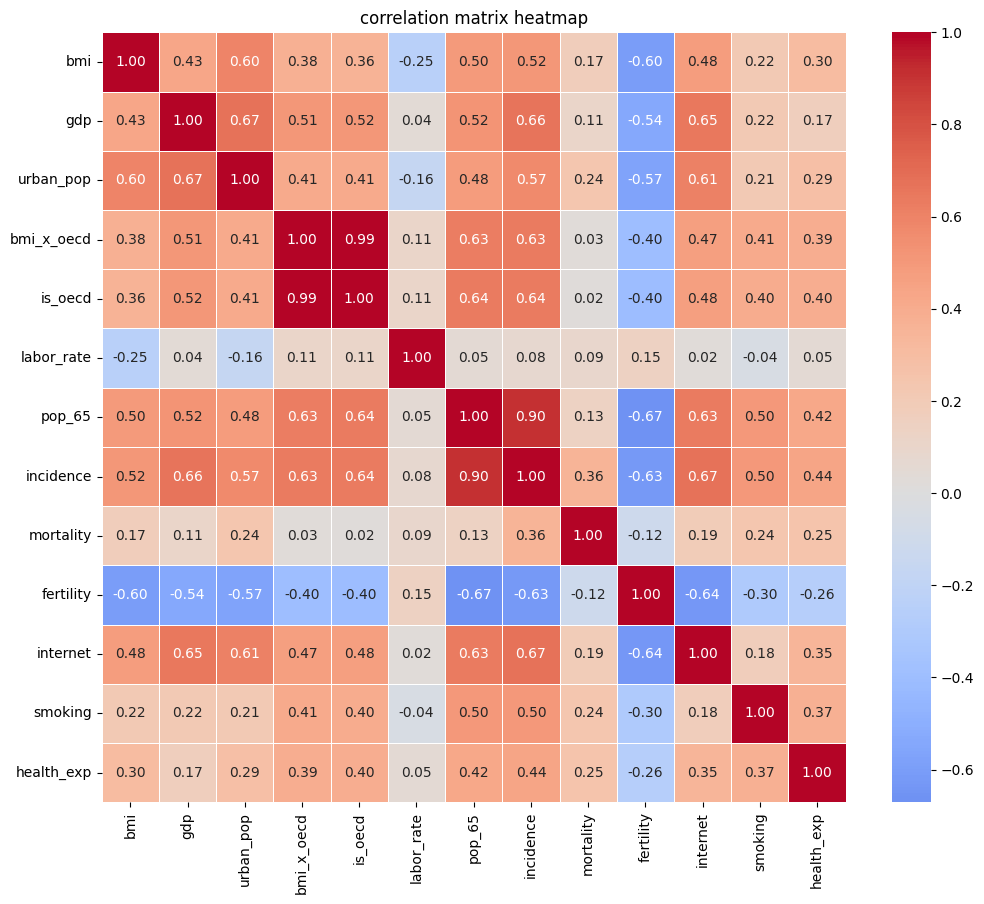

In [60]:
final_df['bmi_x_oecd'] = final_df['bmi']* final_df['is_oecd']
print(final_df['is_oecd'].value_counts())
columns_for_heatmap=['bmi', 'gdp', 'urban_pop', 'bmi_x_oecd', 'is_oecd', 'labor_rate', 'pop_65'
                      ,'incidence', 'mortality', 'fertility','internet','smoking','health_exp']
correlation_matrix = final_df[columns_for_heatmap].corr()
plt.figure(figsize= (12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
plt.title('correlation matrix heatmap')
plt.show()

# Dummy Variables: 

In [61]:
oecd_comparison= final_df.groupby('is_oecd').incidence.mean()
print(final_df['is_oecd'].value_counts())

is_oecd
0    3250
1     816
Name: count, dtype: int64


1. Aging Society Dummy: Based on WHO standards, societies with >10% population over 65 are considered "ageing" or "aged". This captures potential non-linear increases in cancer incidence due to population structure.

In [62]:
final_df['dm_high_aging_society'] = (final_df['pop_65'] > 10).astype(int)
print(final_df['dm_high_aging_society'].value_counts())

dm_high_aging_society
0    2740
1    1326
Name: count, dtype: int64


In [63]:
print(final_df[['year', 'country', 'is_oecd', 'dm_high_aging_society']].head(100))

    year              country  is_oecd  dm_high_aging_society
0   2000                 fiji        0                      0
1   2000             cambodia        0                      0
2   2000             kiribati        0                      0
3   2000           kazakhstan        0                      0
4   2000              jamaica        0                      0
..   ...                  ...      ...                    ...
95  2000               cyprus        0                      0
96  2000  antigua and barbuda        0                      0
97  2001                malta        0                      1
98  2001               canada        1                      1
99  2000                nepal        0                      0

[100 rows x 4 columns]


# interaction of is_oecd variable and gdp

In [64]:
final_df['log_gdp']= np.log(final_df['gdp'])
final_df['log_gdp_is_oecd']= final_df['log_gdp']*final_df['is_oecd']
print(final_df['log_gdp_is_oecd'].head(5))

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: log_gdp_is_oecd, dtype: float64


In [65]:
final_df['is_oecd'] = 0
final_df.loc[final_df['country'].isin(oecd_countries), 'is_oecd'] = 1

# interaction of is_oecd variable and gdp
final_df['log_gdp'] = np.log(final_df['gdp'])
final_df['log_gdp_is_oecd'] = final_df['log_gdp'] * final_df['is_oecd']
# Filling NaNs in Interaction Term: Since 'NaN * 0 = NaN' in Python, rows where is_oecd is 0 but log_gdp is missing(NAN) 
# would incorrectly stay as NaN (and be counted in the results), then filled these with 0 to ensure only real OECD countries with data are counted.
final_df['log_gdp_is_oecd'] = final_df['log_gdp_is_oecd'].fillna(0)

# counting contries :
oecd_count = final_df[final_df['is_oecd'] == 1]['country'].nunique()
interaction_countries = final_df[final_df['log_gdp_is_oecd'] != 0]['country'].nunique()

In [66]:
#print(final_df[['year', 'country', 'gdp_is_oecd', 'dm_high_aging_society', 'dm_high_life_exp']].tail(100))
print(final_df[['country','gdp','is_oecd','log_gdp_is_oecd','dm_high_aging_society']].sample(15).round(2))

                     country       gdp  is_oecd  log_gdp_is_oecd  \
2876                portugal  37943.12        1            10.54   
3130                   ghana   6508.25        0             0.00   
1160            turkmenistan   5360.22        0             0.00   
372                    haiti   3216.80        0             0.00   
3350                 armenia  15052.94        0             0.00   
1984                   gabon  19836.46        0             0.00   
894                 cambodia   3041.10        0             0.00   
2319                malaysia  23307.97        0             0.00   
2937  bosnia and herzegovina  17029.62        0             0.00   
1454                 romania  25760.35        0             0.00   
525                  algeria  11742.59        0             0.00   
1477                 belarus  24012.61        0             0.00   
1714                   samoa   6013.28        0             0.00   
2494                  malawi   1533.23        0 

In [67]:
# start_year=final_df['year'].min()
# end_year=final_df['year'].max()
# print(final_df[['year', 'country', 'dm_high_aging_society', 'dm_high_life_exp']].tail(100))
# start_count= final_df[final_df['year']== start_year]['dm_high_life_exp'].sum() 
# end_count=final_df[final_df['year']== end_year]['dm_high_life_exp'].sum()
# print(f"number of countries with high life_expectency in {start_count}")
# print(f"number of countries with high life_expectency in {end_count}")

# delet percentage of rows with missing value(NA):

In [68]:
missing_report = (final_df.isnull().sum() / len(final_df)) * 100
print(missing_report[missing_report > 0]) 

gdp            2.729956
labor_rate     7.894737
internet       3.713724
health_exp     5.656665
smoking       14.461387
log_gdp        2.729956
dtype: float64


In [69]:
clean_df= final_df.dropna(subset=['mortality', 'gdp', 'pop_65', 'urban_pop', 'fertility', 'labor_rate', 'log_gdp_is_oecd', 'internet','smoking'])
print(f" Missing values after deleting NA in clean_df: {clean_df.isnull().sum()}")

 Missing values after deleting NA in clean_df: country                    0
year                       0
incidence                  0
mortality                  0
gdp                        0
bmi                        0
pop_65                     0
urban_pop                  0
fertility                  0
labor_rate                 0
internet                   0
health_exp               134
smoking                    0
is_oecd                    0
bmi_x_oecd                 0
dm_high_aging_society      0
log_gdp                    0
log_gdp_is_oecd            0
dtype: int64


# Building stepwise regression

# Step 1: Adding gdp and urbanisation:

In [70]:
df_step= clean_df.set_index(['country', 'year'])
exog_1_fe= sm.add_constant(df_step[['log_gdp', 'urban_pop']])
model_1_fe=PanelOLS(df_step['mortality'],exog_1_fe, entity_effects=True, time_effects=True).fit()
print(model_1_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.1127
Estimator:                   PanelOLS   R-squared (Between):             -2.4959
No. Observations:                3220   R-squared (Within):               0.0667
Date:                Tue, Mar 24 2026   R-squared (Overall):             -2.0516
Time:                        12:51:22   Log-likelihood                   -7454.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      194.16
Entities:                         137   P-value                           0.0000
Avg Obs:                       23.504   Distribution:                  F(2,3058)
Min Obs:                       18.000                                           
Max Obs:                       24.000   F-statistic (robust):             194.16
                            

# Step 2: Adding Pop_65:

In [71]:
exog_2_fe = df_step[['log_gdp', 'urban_pop', 'pop_65']]
model_2_fe = PanelOLS(df_step['mortality'], exog_2_fe, entity_effects=True, time_effects=True).fit()
print(model_2_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3016
Estimator:                   PanelOLS   R-squared (Between):              0.6848
No. Observations:                3220   R-squared (Within):               0.2266
Date:                Tue, Mar 24 2026   R-squared (Overall):              0.6770
Time:                        12:51:23   Log-likelihood                   -7068.6
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      439.99
Entities:                         137   P-value                           0.0000
Avg Obs:                       23.504   Distribution:                  F(3,3057)
Min Obs:                       18.000                                           
Max Obs:                       24.000   F-statistic (robust):             439.99
                            

# Step 3: Adding Labor Rate:

In [72]:
exog_3_fe=sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate']])
model_3_fe=PanelOLS(df_step['mortality'], exog_3_fe, entity_effects=True, time_effects=True).fit()
print(model_3_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3259
Estimator:                   PanelOLS   R-squared (Between):             -2.2644
No. Observations:                3220   R-squared (Within):               0.2470
Date:                Tue, Mar 24 2026   R-squared (Overall):             -1.8386
Time:                        12:51:23   Log-likelihood                   -7011.6
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      369.31
Entities:                         137   P-value                           0.0000
Avg Obs:                       23.504   Distribution:                  F(4,3056)
Min Obs:                       18.000                                           
Max Obs:                       24.000   F-statistic (robust):             369.31
                            

# Step 4: Adding BMI:

In [73]:
exog_4_fe=sm.add_constant(df_step[['log_gdp','urban_pop', 'pop_65', 'labor_rate', 'bmi']])
model_4_fe=PanelOLS(df_step['mortality'], exog_4_fe, entity_effects=True, time_effects= True).fit()
print(model_4_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3724
Estimator:                   PanelOLS   R-squared (Between):             -2.0586
No. Observations:                3220   R-squared (Within):               0.2472
Date:                Tue, Mar 24 2026   R-squared (Overall):             -1.6586
Time:                        12:51:23   Log-likelihood                   -6896.4
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      362.57
Entities:                         137   P-value                           0.0000
Avg Obs:                       23.504   Distribution:                  F(5,3055)
Min Obs:                       18.000                                           
Max Obs:                       24.000   F-statistic (robust):             362.57
                            

# Step 5:Adding is_oecd as Dummy Variable:

In [74]:
exog_5_fe=sm.add_constant(df_step[['log_gdp','urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd']])
model_5_fe=PanelOLS(df_step['mortality'], exog_5_fe, entity_effects=True, time_effects=True).fit()
print(model_5_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3782
Estimator:                   PanelOLS   R-squared (Between):             -11.155
No. Observations:                3220   R-squared (Within):               0.2516
Date:                Tue, Mar 24 2026   R-squared (Overall):             -9.3512
Time:                        12:51:23   Log-likelihood                   -6881.5
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      309.57
Entities:                         137   P-value                           0.0000
Avg Obs:                       23.504   Distribution:                  F(6,3054)
Min Obs:                       18.000                                           
Max Obs:                       24.000   F-statistic (robust):             309.57
                            

# Step 6: Adding High aging society as Dummy Variable:

In [75]:
exog_6_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd', 'dm_high_aging_society']])
model_6_fe = PanelOLS(df_step['mortality'], exog_6_fe, entity_effects=True, time_effects=True).fit()
print(model_6_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3818
Estimator:                   PanelOLS   R-squared (Between):             -11.515
No. Observations:                3220   R-squared (Within):               0.2635
Date:                Tue, Mar 24 2026   R-squared (Overall):             -9.6522
Time:                        12:51:23   Log-likelihood                   -6872.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      269.42
Entities:                         137   P-value                           0.0000
Avg Obs:                       23.504   Distribution:                  F(7,3053)
Min Obs:                       18.000                                           
Max Obs:                       24.000   F-statistic (robust):             269.42
                            

# create labor_rate * is_oecd variable:

In [80]:
df_step['labor_rate * is_oecd']= df_step['labor_rate']* df_step['is_oecd']

# Step 7: Adding labor_rate * is_oecd:

In [81]:
exog_7_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd', 'dm_high_aging_society',
                                     'labor_rate * is_oecd']])
model_7_fe = PanelOLS(df_step['mortality'], exog_7_fe, entity_effects=True, time_effects= True).fit()
print(model_7_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3874
Estimator:                   PanelOLS   R-squared (Between):             -8.6866
No. Observations:                3220   R-squared (Within):               0.2527
Date:                Tue, Mar 24 2026   R-squared (Overall):             -7.2664
Time:                        12:53:11   Log-likelihood                   -6857.5
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      241.24
Entities:                         137   P-value                           0.0000
Avg Obs:                       23.504   Distribution:                  F(8,3052)
Min Obs:                       18.000                                           
Max Obs:                       24.000   F-statistic (robust):             241.24
                            

# Step 8: Adding internet:

In [82]:
exog_8_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society', 'labor_rate * is_oecd','internet']])
model_8_fe = PanelOLS(df_step['mortality'], exog_8_fe, entity_effects=True, time_effects= True).fit()
print(model_8_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3957
Estimator:                   PanelOLS   R-squared (Between):             -9.2722
No. Observations:                3220   R-squared (Within):               0.1207
Date:                Tue, Mar 24 2026   R-squared (Overall):             -7.7841
Time:                        12:53:42   Log-likelihood                   -6835.6
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      221.96
Entities:                         137   P-value                           0.0000
Avg Obs:                       23.504   Distribution:                  F(9,3051)
Min Obs:                       18.000                                           
Max Obs:                       24.000   F-statistic (robust):             221.96
                            

# Step  9: Adding smoking:

In [84]:
exog_9_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society', 'labor_rate * is_oecd','internet'
                                       ,'smoking']])
model_9_fe = PanelOLS(df_step['mortality'], exog_9_fe, entity_effects=True, time_effects= True).fit()
print(model_9_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.4201
Estimator:                   PanelOLS   R-squared (Between):             -4.5856
No. Observations:                3220   R-squared (Within):              -0.0946
Date:                Tue, Mar 24 2026   R-squared (Overall):             -3.8675
Time:                        12:54:18   Log-likelihood                   -6769.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      220.98
Entities:                         137   P-value                           0.0000
Avg Obs:                       23.504   Distribution:                 F(10,3050)
Min Obs:                       18.000                                           
Max Obs:                       24.000   F-statistic (robust):             220.98
                            

# step 10: adding health_exp:

In [86]:
exog_10_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd','dm_high_aging_society'
                                      , 'labor_rate * is_oecd','internet','smoking']])
model_10_fe = PanelOLS(df_step['mortality'], exog_10_fe, entity_effects=True, time_effects= True).fit()
print(model_10_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.4201
Estimator:                   PanelOLS   R-squared (Between):             -4.5856
No. Observations:                3220   R-squared (Within):              -0.0946
Date:                Tue, Mar 24 2026   R-squared (Overall):             -3.8675
Time:                        12:55:01   Log-likelihood                   -6769.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      220.98
Entities:                         137   P-value                           0.0000
Avg Obs:                       23.504   Distribution:                 F(10,3050)
Min Obs:                       18.000                                           
Max Obs:                       24.000   F-statistic (robust):             220.98
                            

# step 11: adding Fertality variable:

In [87]:
exog_11_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd','dm_high_aging_society',
                                     'labor_rate * is_oecd','internet','smoking','fertility']])
model_11_fe = PanelOLS(df_step['mortality'], exog_11_fe, entity_effects=True, time_effects= True).fit()
print(model_11_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.4550
Estimator:                   PanelOLS   R-squared (Between):             -2.4917
No. Observations:                3220   R-squared (Within):               0.3466
Date:                Tue, Mar 24 2026   R-squared (Overall):             -2.0162
Time:                        12:55:26   Log-likelihood                   -6669.3
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      231.37
Entities:                         137   P-value                           0.0000
Avg Obs:                       23.504   Distribution:                 F(11,3049)
Min Obs:                       18.000                                           
Max Obs:                       24.000   F-statistic (robust):             231.37
                            

# Comparing results of all Fixed Effect models:

In [88]:
Compare_results_fixed_Effect = compare({
    'FE model 1': model_1_fe,
    'FE model 2': model_2_fe,
    'FE model 3': model_3_fe,
    'FE model 4': model_4_fe,
    'FE model 5': model_5_fe,
    'FE model 6': model_6_fe,
    'FE model 7': model_7_fe,
    'FE model 8': model_8_fe,
    'FE model 9': model_9_fe,
    'FE model 10': model_10_fe,
    'FE model 11': model_11_fe
    })

print(Compare_results_fixed_Effect)

                                                                                       Model Comparison                                                                                       
                              FE model 1     FE model 2     FE model 3     FE model 4     FE model 5     FE model 6     FE model 7     FE model 8     FE model 9    FE model 10    FE model 11
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Dep. Variable                  mortality      mortality      mortality      mortality      mortality      mortality      mortality      mortality      mortality      mortality      mortality
Estimator                       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS
No. Observations                    3220     